# Task 4 — Empirical Analysis of ETFs

## Objective
- Pick a sector ETF (in the US, for example, XLRE)
- Find the 30 largest holdings.
- Get at least 6 months of data
- Compute the daily returns.
- Compute the covariance matrix, PCA, SVD


In [10]:
tickers = [
    "WELL","PLD","AMT","EQIX","SPG","DLR","PSA","O","CBRE","CCI",
    "CSGP","VICI","VTR","IRM","EXR","AVB","EQR","SBAC","WY","ESS",
    "INVH","MAA","KIM","DOC","ARE","REG","BXP","CPT","UDR","HST","FRT"
]


In [13]:
import yfinance as yf
import pandas as pd

tickers = [
    "WELL","PLD","AMT","EQIX","SPG","DLR","PSA","O","CBRE","CCI",
    "CSGP","VICI","VTR","IRM","EXR","AVB","EQR","SBAC","WY","ESS",
    "INVH","MAA","KIM","DOC","ARE","REG","BXP","CPT","UDR","HST","FRT"
]

# Download 6 months daily data
data = yf.download(tickers, period="6mo", interval="1d", group_by='ticker', auto_adjust=True)

# Extract adjusted close prices for all tickers
adj_close = pd.DataFrame({ticker: data[ticker]['Close'] for ticker in tickers})

# Quick check
print(adj_close.head())

# Compute daily returns
returns = adj_close.pct_change().dropna()
print(returns.head())


[*********************100%***********************]  31 of 31 completed


                  WELL        PLD         AMT        EQIX         SPG  \
Date                                                                    
2025-04-04  142.001038  96.441208  214.774765  757.486206  142.460098   
2025-04-07  137.561340  92.798759  208.160904  739.226440  139.816711   
2025-04-08  135.262207  88.125450  199.644836  731.643799  136.919708   
2025-04-09  140.217239  96.431381  202.395737  788.350708  149.414841   
2025-04-10  140.534363  93.162025  203.215149  761.964600  144.059784   

                   DLR         PSA          O        CBRE        CCI  ...  \
Date                                                                  ...   
2025-04-04  135.589569  278.795349  53.630093  118.080002  98.793571  ...   
2025-04-07  134.771103  270.133514  51.471275  117.150002  96.083549  ...   
2025-04-08  134.218887  260.942566  50.829468  113.940002  92.776733  ...   
2025-04-09  143.744659  276.600494  52.492340  121.269997  93.471359  ...   
2025-04-10  140.313004  27

In [14]:
# Compute daily returns
returns = adj_close.pct_change().dropna()

# Quick look
print(returns.head())


                WELL       PLD       AMT      EQIX       SPG       DLR  \
Date                                                                     
2025-04-07 -0.031265 -0.037769 -0.030794 -0.024106 -0.018555 -0.006036   
2025-04-08 -0.016714 -0.050360 -0.040911 -0.010258 -0.020720 -0.004097   
2025-04-09  0.036633  0.094251  0.013779  0.077506  0.091259  0.070972   
2025-04-10  0.002262 -0.033903  0.004049 -0.033470 -0.035840 -0.023873   
2025-04-11  0.006064  0.014122  0.031943  0.007902  0.003453  0.019678   

                 PSA         O      CBRE       CCI  ...       MAA       KIM  \
Date                                                ...                       
2025-04-07 -0.031069 -0.040254 -0.007876 -0.027431  ... -0.015482 -0.010352   
2025-04-08 -0.034024 -0.012469 -0.027401 -0.034416  ... -0.004910 -0.021967   
2025-04-09  0.060005  0.032715  0.064332  0.007487  ...  0.052544  0.078075   
2025-04-10 -0.014949  0.003149 -0.038097 -0.003977  ... -0.018879 -0.019345   
2025-04

In [15]:
cov_matrix = returns.cov()

# Check shape and some values
print(cov_matrix.shape)
print(cov_matrix.head())


(31, 31)
          WELL       PLD       AMT      EQIX       SPG       DLR       PSA  \
WELL  0.000161  0.000086  0.000065  0.000078  0.000064  0.000055  0.000101   
PLD   0.000086  0.000310  0.000069  0.000179  0.000205  0.000126  0.000190   
AMT   0.000065  0.000069  0.000228  0.000071  0.000026  0.000043  0.000098   
EQIX  0.000078  0.000179  0.000071  0.000333  0.000139  0.000172  0.000135   
SPG   0.000064  0.000205  0.000026  0.000139  0.000249  0.000111  0.000145   

             O      CBRE       CCI  ...       MAA       KIM       DOC  \
WELL  0.000079  0.000090  0.000076  ...  0.000072  0.000065  0.000071   
PLD   0.000094  0.000216  0.000078  ...  0.000159  0.000199  0.000154   
AMT   0.000093  0.000014  0.000178  ...  0.000049  0.000029  0.000067   
EQIX  0.000068  0.000153  0.000080  ...  0.000119  0.000127  0.000074   
SPG   0.000072  0.000199  0.000037  ...  0.000145  0.000182  0.000126   

           ARE       REG       BXP       CPT       UDR       HST       FRT  
WELL  

In [16]:
from sklearn.decomposition import PCA
import numpy as np

# Perform PCA
pca = PCA()
pca.fit(returns)

# Explained variance
explained_variance = pca.explained_variance_ratio_
print("Explained variance ratio:", explained_variance)

# Principal components
components = pca.components_
print("Principal components shape:", components.shape)


Explained variance ratio: [0.55627916 0.09354006 0.05118129 0.04816953 0.03376923 0.02929359
 0.02553775 0.01957937 0.01860981 0.01695884 0.01447221 0.01211171
 0.01195151 0.00959757 0.00871783 0.00751306 0.00706479 0.00545646
 0.00487413 0.00418627 0.00338557 0.00276409 0.00253112 0.00244705
 0.0021028  0.00176989 0.00166083 0.00151443 0.00128927 0.00098085
 0.00068996]
Principal components shape: (31, 31)


In [17]:
U, S, Vt = np.linalg.svd(returns, full_matrices=False)

print("U shape:", U.shape)  # left singular vectors
print("S shape:", S.shape)  # singular values
print("Vt shape:", Vt.shape)  # right singular vectors


U shape: (125, 31)
S shape: (31,)
Vt shape: (31, 31)


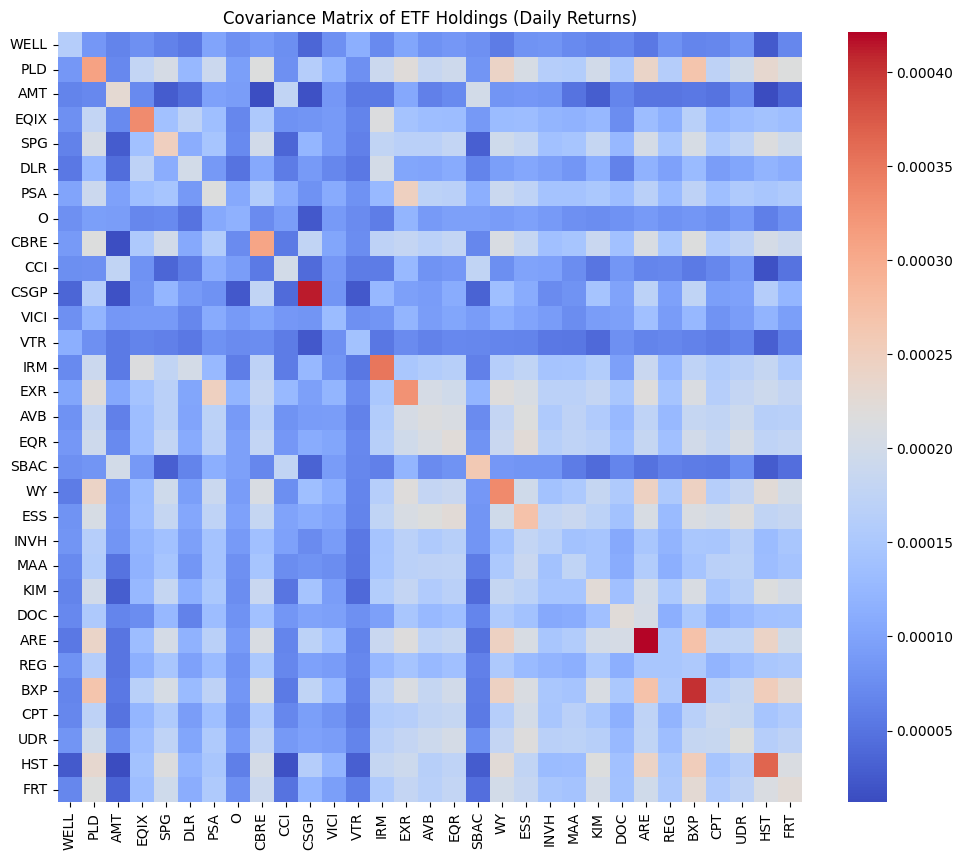

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,10))
sns.heatmap(cov_matrix, annot=False, cmap='coolwarm')
plt.title("Covariance Matrix of ETF Holdings (Daily Returns)")
plt.show()


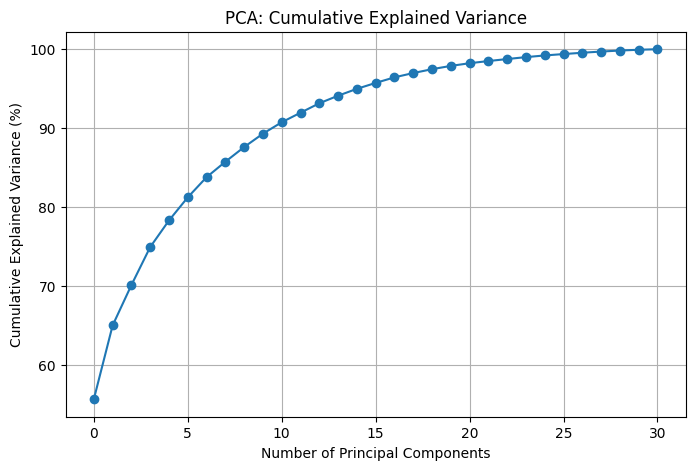

In [19]:
plt.figure(figsize=(8,5))
plt.plot(np.cumsum(explained_variance)*100, marker='o')
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance (%)")
plt.title("PCA: Cumulative Explained Variance")
plt.grid(True)
plt.show()


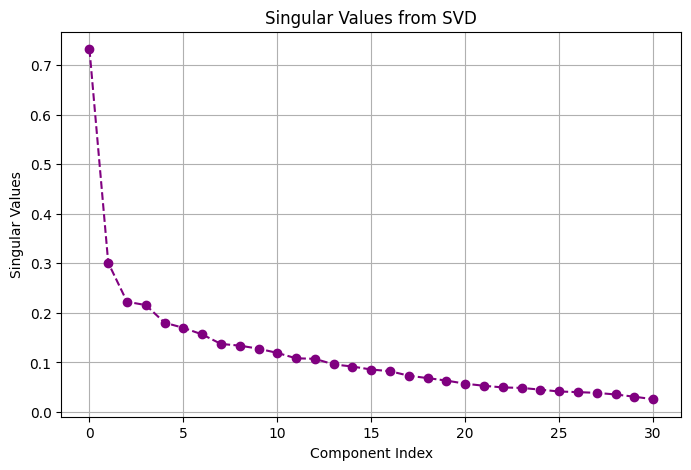

In [20]:
plt.figure(figsize=(8,5))
plt.plot(S, marker='o', linestyle='--', color='purple')
plt.xlabel("Component Index")
plt.ylabel("Singular Values")
plt.title("Singular Values from SVD")
plt.grid(True)
plt.show()


- Daily returns are important because they normalize the price data and allow us to analyze risk and correlation.
- Covariance matrix shows how holdings move relative to each other; positive means moving together, negative means opposite.
- PCA reduces dimensionality, highlights dominant patterns in returns. Explained variance tells us how much of total risk each principal component captures.
- SVD is mathematically related to PCA; singular values indicate variance captured, and U, Vt matrices show the left/right singular vectors (similar to eigenvectors).
- Both PCA and SVD help in understanding structure, spotting hidden correlations, and reducing noise for portfolio analysis.
